In [1]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:

dataset_name_source_list = ["dwq_sentinel2", "xj_sentinel2"]
dataset_name_target_list = dataset_name_source_list[::-1]
batch_size = 4
# result_path = r"E:\Yiling\at_SIAT_research\z_result\20241025_transfer_metric_FD_weighted_y_diff\20241025_6_label1_FID_all-batch4_dwqs2-xjs2_100img"
result_path = r"E:\Yiling\at_SIAT_research\z_result\20241025_transfer_metric_FD_weighted_y_diff\20241025_2_-_FID_all-batch4_dwqs2-xjs2_100img"

# load the result_list_dict
result_list_dict_name = f"result_list_dict_{dataset_name_source_list[0]}-{dataset_name_target_list[0]}_batch{batch_size}.json"
result_list_dict_path = os.path.join(result_path, result_list_dict_name)
with open(result_list_dict_path, 'r') as f:
    result_list_dict = json.load(f)

for key in result_list_dict.keys():
    print(key, len(result_list_dict[key]), len(result_list_dict[key][0]))

dwq_sentinel2_cls_1 90 43
dwq_sentinel2_cls_2 1 43
dwq_sentinel2_cls_3 37 43
dwq_sentinel2_cls_6 16 43
dwq_sentinel2_cls_7 4 43
dwq_sentinel2_cls_8 296 43
xj_sentinel2_cls_1 109 43
xj_sentinel2_cls_2 512 43
xj_sentinel2_cls_3 4 43
xj_sentinel2_cls_6 44 43
xj_sentinel2_cls_7 151 43
xj_sentinel2_cls_8 49 43


In [3]:
with open("./result_list_name_FD", "r") as file:
    result_list_name = json.load(file)["result_list_name"]
print(len(result_list_name))
for i in range(len(result_list_name)):
    print(i, result_list_name[i])

43
0 source
1 target
2 class_index
3 class_name
4 OA_delta
5 F1_delta
6 precision_delta
7 mean_dif_absolute_sum
8 mean_dif_absolute_abs_sum
9 mean_dif_relative_sum
10 mean_dif_relative_abs_sum
11 mean_dif_absolute_y0_y1_diff
12 mean_dif_absolute_abs_y0_y1_diff
13 mean_dif_relative_y0_y1_diff
14 mean_dif_relative_abs_y0_y1_diff
15 mean_dif_absolute_normalized_y0_y1_diff
16 mean_dif_relative_normalized_y0_y1_diff
17 mean_dif_absolute_abs_normalized_y0_y1_diff
18 mean_dif_relative_abs_normalized_y0_y1_diff
19 mean_dif_absolute_y0_y1_diff_abs
20 mean_dif_absolute_abs_y0_y1_diff_abs
21 mean_dif_relative_y0_y1_diff_abs
22 mean_dif_relative_abs_y0_y1_diff_abs
23 mean_dif_absolute_normalized_y0_y1_diff_abs
24 mean_dif_relative_normalized_y0_y1_diff_abs
25 mean_dif_absolute_abs_normalized_y0_y1_diff_abs
26 mean_dif_relative_abs_normalized_y0_y1_diff_abs
27 mean_dif_absolute_y0_y1_diff_normalized
28 mean_dif_absolute_abs_y0_y1_diff_normalized
29 mean_dif_relative_y0_y1_diff_normalized
30 mean_di

In [4]:
df_dict = {}
for key in result_list_dict.keys():
    df_dict[key] = pd.DataFrame(result_list_dict[key], columns=result_list_name)

for key in df_dict.keys():
    print(key, df_dict[key].shape)

dwq_sentinel2_cls_1 (90, 43)
dwq_sentinel2_cls_2 (1, 43)
dwq_sentinel2_cls_3 (37, 43)
dwq_sentinel2_cls_6 (16, 43)
dwq_sentinel2_cls_7 (4, 43)
dwq_sentinel2_cls_8 (296, 43)
xj_sentinel2_cls_1 (109, 43)
xj_sentinel2_cls_2 (512, 43)
xj_sentinel2_cls_3 (4, 43)
xj_sentinel2_cls_6 (44, 43)
xj_sentinel2_cls_7 (151, 43)
xj_sentinel2_cls_8 (49, 43)


In [8]:
# 从 OA_delta 往后取
selected_columns = result_list_name[4:]

df_corr_F1_diff = pd.DataFrame(columns=selected_columns)

index_name = "OA_delta" # F1_delta
for key in df_dict.keys():
    temp_df_select = df_dict[key][selected_columns]
    temp_correlation_matrix = temp_df_select.corr(method='pearson') # method='pearson' 'spearman' 'spearman'
    df_corr_F1_diff.loc[key + "_" + index_name] = temp_correlation_matrix[index_name]

# abs, mean
df_corr_F1_diff.loc["mean"] = df_corr_F1_diff.mean()
df_corr_F1_diff.loc["abs_mean"] = df_corr_F1_diff.abs().mean()

print(df_corr_F1_diff.iloc[:, :2])

                              OA_delta  F1_delta
dwq_sentinel2_cls_1_OA_delta       1.0  0.693064
dwq_sentinel2_cls_2_OA_delta       NaN       NaN
dwq_sentinel2_cls_3_OA_delta       1.0  0.896469
dwq_sentinel2_cls_6_OA_delta       1.0  0.835064
dwq_sentinel2_cls_7_OA_delta       1.0  0.999247
dwq_sentinel2_cls_8_OA_delta       1.0  0.270968
xj_sentinel2_cls_1_OA_delta        1.0  0.622989
xj_sentinel2_cls_2_OA_delta        1.0  0.802112
xj_sentinel2_cls_3_OA_delta        1.0  0.985719
xj_sentinel2_cls_6_OA_delta        1.0  0.989239
xj_sentinel2_cls_7_OA_delta        1.0  0.932466
xj_sentinel2_cls_8_OA_delta        1.0  0.900132
mean                               1.0  0.811588
abs_mean                           1.0  0.811588


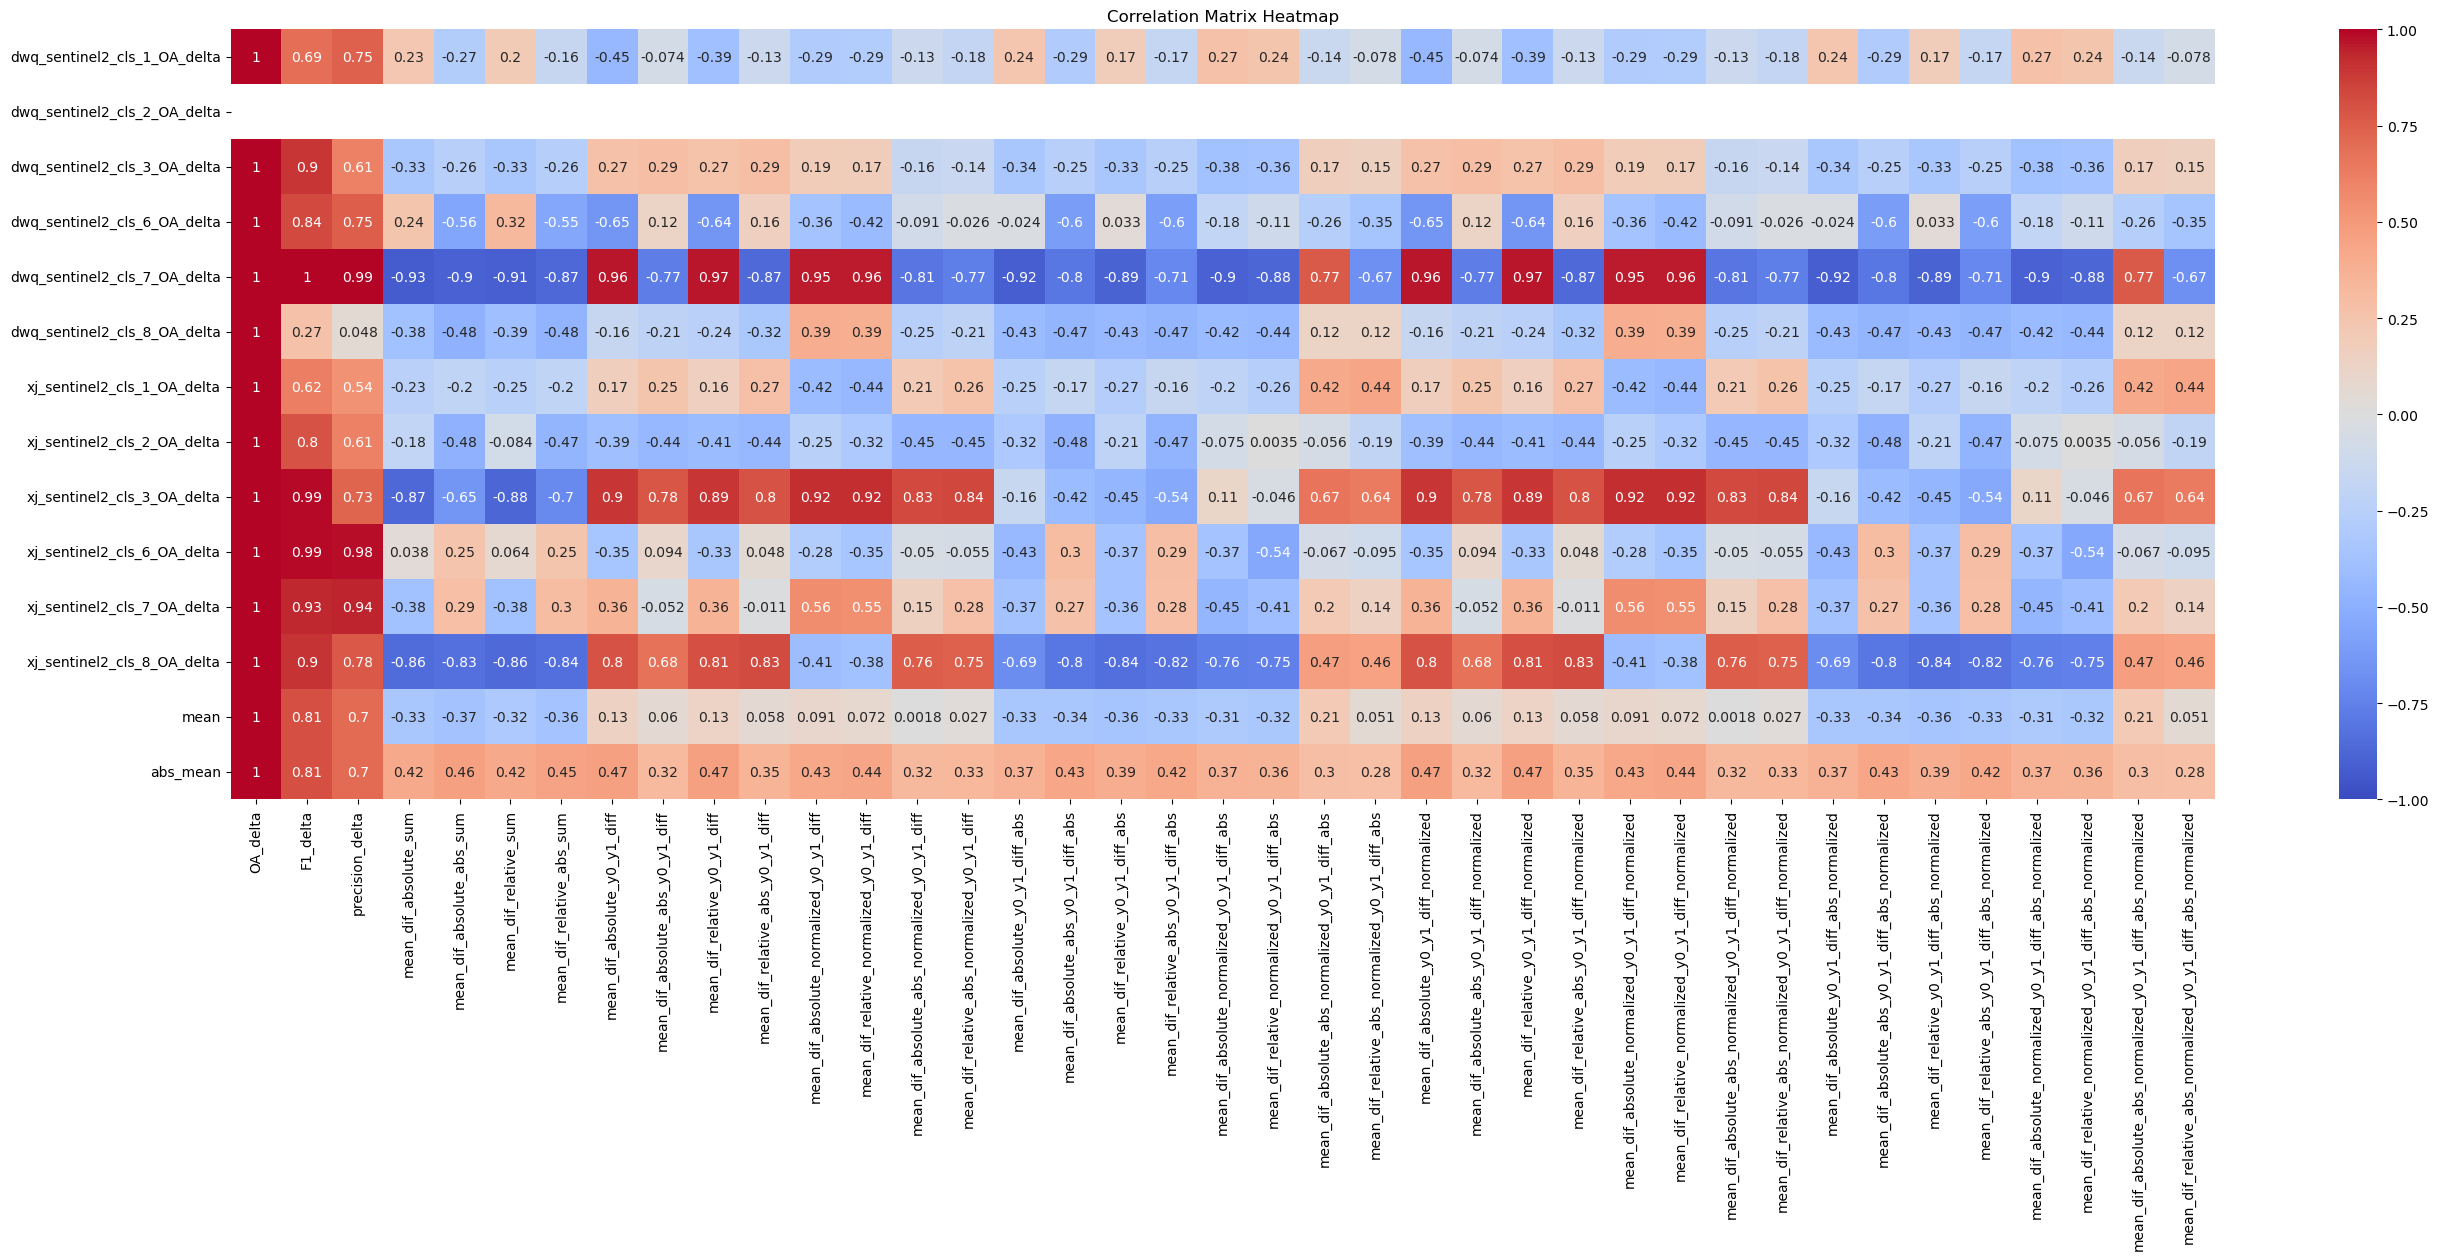

(14, 39)


In [9]:
# plot the correlation matrix heatmap
heatmap_data = df_corr_F1_diff.iloc[:, :]
figsize_scale = 4
plt.figure(figsize=(8 * figsize_scale, 2.5 * figsize_scale))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()
print(heatmap_data.shape)

In [10]:
heatmap_data.to_csv("./FD/dwq_s2_xj_s2_no-label_OA-delta_pearson_corr_heatmap_data.csv")